# Modelagem — Steam (Dataset V2)
### TCC — Análise Preditiva da Popularidade de Jogos na Steam Utilizando Redes Neurais

**Discente:** Davi Augusto Farinela da Silva
**Orientador:** Prof. Dr. João Henrique Ferreira Flores

---

Esse notebook começa a etapa de modelagem, dando sequência ao EDA (`steam-eda-v2.ipynb`). Ele parte de três pontas soltas que eu mesmo deixei registradas lá no final:

1. **`is_free` com correlação de −0,37 com `log_reviews`**, que eu achei contra-intuitivo e escrevi que valia investigar melhor antes de concluir qualquer coisa.
2. **O viés de janela de acúmulo do `release_year`** — `reviews_total` é contagem acumulada desde o lançamento, então jogo antigo teve mais tempo para juntar avaliação.
3. **A ressalva do `review_score_desc`**, que mistura "sem avaliação" com "poucas avaliações" sob o mesmo rótulo.

Além disso, revisando o pipeline para começar a modelar, eu encontrei um **bug na coluna de preço** que precisa ser corrigido antes de qualquer modelo (trato disso logo na seção 2.)

## 1. Carregamento e Configuração

Uso a base curada de sempre (`data/steam-jogos-v2.csv`, 118.596 jogos) e junto com as features novas extraídas do checkpoint (`data/steam-features-v2.csv`).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

# Paleta (mesma paleta usada no resto do projeto)
BLUE    = "#2a78d6"
ORANGE  = "#eb6834"
AQUA    = "#1baf7a"
YELLOW  = "#eda100"
RED     = "#e34948"
INK     = "#0b0b0b"
INK_2   = "#52514e"
MUTED   = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor":   "#fcfcfb",
    "axes.edgecolor":   MUTED,
    "axes.labelcolor":  INK_2,
    "text.color":       INK,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "grid.color":       "#e1e0d9",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size": 10,
})

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)

# Data de referência: quando data/steam-jogos-v2.csv foi gerado. É o "hoje" da base
# — uso ela para calcular há quanto tempo cada jogo está no mercado.
REF = pd.Timestamp("2026-08-10")

df = pd.read_csv("data/steam-jogos-v2.csv", encoding="utf-8-sig")
ft = pd.read_csv("data/steam-features-v2.csv", encoding="utf-8-sig")

df = df.merge(ft, on="appid", how="left", validate="one_to_one")
df["release_date"] = pd.to_datetime(df["release_date"])
df["log_reviews"]  = np.log1p(df["reviews_total"])

print(f"jogos:    {len(df):,}")
print(f"colunas:  {df.shape[1]} (51 da base curada + {ft.shape[1]-1} novas)")
print(f"período:  {df.release_date.min():%d/%m/%Y} a {df.release_date.max():%d/%m/%Y}")

jogos:    118,596
colunas:  78 (51 da base curada + 26 novas)
período:  30/06/1997 a 06/08/2026


As colunas novas que vieram do checkpoint sem custo de coleta:

In [2]:
novas = [c for c in ft.columns if c != "appid"]
print(", ".join(novas))

coming_soon, desenvolvedora, n_desenvolvedoras, distribuidora, n_distribuidoras, auto_publicado, n_screenshots, n_videos, tem_trailer, tem_site, suporte_controle, n_pacotes, desc_curta_chars, desc_longa_chars, desc_curta_palavras, header_image, price_currency, price_valor, price_desconto_pct, price_formatado, n_descritores_conteudo, conteudo_adulto, dejus_idade, n_sistemas_rating, req_min_chars, tem_req_recomendado


## 2. Correção do preço

Esse é o bug. O `scripts/steam-analise-v2.py` monta o preço assim:

```python
"price_brl": price.get("final", 0) / 100 if price else None
```

Ou seja, pega o campo `final` do bloco `price_overview` e divide por 100, assumindo que todo mundo veio em reais e em centavos. Só que a Steam não devolveu tudo em BRL — a requisição do coletor não fixou o país (`cc=BR`), então uma fatia dos apps voltou com preço regional de outro lugar. E o campo `currency` estava no payload o tempo todo, só não tinha sido aproveitado.

In [3]:
com_preco = df[df["price_currency"].notna()]
contagem  = com_preco["price_currency"].value_counts()
n_fora    = int((com_preco["price_currency"] != "BRL").sum())

print(f"jogos com bloco de preço:  {len(com_preco):,}")
print(f"em BRL:                    {int(contagem.get('BRL', 0)):,}")
print(f"em outra moeda:            {n_fora:,} ({100*n_fora/len(com_preco):.2f}%)")
print()
print(contagem.head(10).to_string())

jogos com bloco de preço:  101,033
em BRL:                    99,033
em outra moeda:            2,000 (1.98%)

price_currency
BRL    99033
USD      712
EUR      692
CAD      202
VND      137
AUD       77
GBP       60
JPY       22
IDR       13
ILS       13


E é isso que estava produzindo os preços absurdos que eu não tinha notado no EDA:

In [4]:
fora = com_preco[com_preco["price_currency"] != "BRL"]
amostra = fora.nlargest(6, "price_valor")[["name", "price_currency", "price_formatado", "price_brl"]]
amostra = amostra.rename(columns={"price_brl": "price_brl (errado)"})
amostra

,name,price_currency,price_formatado,price_brl (errado)
92164,Nicktoons & The Dice of Destiny,VND,585.000₫,585000.0
49204,HOT WHEELS UNLEASHED™,IDR,Rp 579 000,579000.0
32192,Atomic Heart,IDR,Rp 549 000,549000.0
15110,IXION,VND,445.000₫,445000.0
80854,魔女的夜宴,VND,445.000₫,445000.0
80672,Free.ksPeak,VND,381.500₫,381500.0


Atomic Heart não custa R$ 549.000 — custa Rp 549.000, rupias indonésias, algo em torno de R$ 180. E o campeão da base, com "R$ 585.000", eram 585.000 dongs vietnamitas.

Como não quero fazer coleta nova, a correção que adoto é conservadora: **mantenho o preço só onde a moeda é BRL e marco o resto como faltante**. Perco o preço de 2 mil jogos pagos, mas não invento taxa de câmbio (que ainda por cima teria que ser a taxa da data de cada coleta, que eu não tenho). Jogo gratuito continua com preço zero.

In [5]:
df["preco_brl"] = np.where(df["price_currency"].eq("BRL"), df["price_valor"] / 100, np.nan)
df.loc[df["is_free"], "preco_brl"] = 0.0

pagos = ~df["is_free"]
antes  = df.loc[pagos, "price_brl"]
depois = df.loc[pagos, "preco_brl"]

comp = pd.DataFrame({
    "antes (price_brl)":  [antes.max(), antes.mean(), antes.median(), antes.quantile(.99), antes.isna().sum()],
    "depois (preco_brl)": [depois.max(), depois.mean(), depois.median(), depois.quantile(.99), depois.isna().sum()],
}, index=["máximo", "média", "mediana", "p99", "faltantes"]).round(2)
print("Jogos pagos:\n")
print(comp.to_string())

Jogos pagos:

           antes (price_brl)  depois (preco_brl)
máximo             585000.00             4999.34
média                 206.12               25.55
mediana                16.99               16.99
p99                   162.00              149.50
faltantes               0.00             1999.00


A média de preço dos jogos pagos cai de **R$ 206 para R$ 25,55**, e o máximo de R$ 585.000 para R$ 4.999. A mediana nem se move (R$ 16,99 nos dois casos), o que confirma que o problema era todo de cauda, 2% das linhas estavam distorcendo média, desvio e qualquer padronização que eu fosse aplicar depois.

ACHO que vale registrar para a metodologia: isso não muda o número de jogos da base (continuam 118.596), só a qualidade da coluna de preço.

### O que essa correção muda no EDA

Preciso registrar isso porque no EDA passado eu tratei errado.Lá eu notei que
existiam 189 jogos listados acima de R$ 1.000, escrevi que aquilo "parecia erro de dado" e resolvi
capando o preço em R$ 1.000. O corte não ta errado, mas ta mirando na coisa errada: ele pega
os preços que *parecem* absurdos (rupia, dongue, essas moedas diferenciadas ai), e deixa passar todos os que vieram em dólar, euro
ou dólar canadense, que caem num intervalo perfeitamente plausível em real. 

Um jogo de US$ 59,99 vira"R$ 59,99" na coluna e não levanta suspeita nenhuma.

Vale medir quanto passou, e o que isso faz com a conclusão que eu tirei sobre preço.

In [6]:
pagos = df[~df["is_free"]]
fora  = pagos[pagos["price_currency"].notna() & pagos["price_currency"].ne("BRL")]

print(f"jogos pagos em moeda estrangeira:        {len(fora):,}")
print(f"  pegos pelo corte de R$ 1.000 do EDA:   {(fora['price_brl'] >  1000).sum():,}")
print(f"  passaram despercebidos abaixo dele:    {(fora['price_brl'] <= 1000).sum():,}")
print()
print(fora.loc[fora["price_brl"] <= 1000, "price_currency"].value_counts().head(5).to_string())

# a correlação da seção de correlações do EDA, refeita na mesma base
print()
print(f"corr(preço, log_reviews) — coluna antiga: {df['price_brl'].corr(df['log_reviews']):.4f}")
print(f"corr(preço, log_reviews) — coluna nova:   {df['preco_brl'].corr(df['log_reviews']):.4f}")

jogos pagos em moeda estrangeira:        1,999
  pegos pelo corte de R$ 1.000 do EDA:   179
  passaram despercebidos abaixo dele:    1,820

price_currency
USD    712
EUR    692
CAD    202
AUD     77
GBP     60

corr(preço, log_reviews) — coluna antiga: 0.0199
corr(preço, log_reviews) — coluna nova:   0.1912


Aí está o estrago. O corte pegou só uma fração dos jogos em moeda estrangeira a grande maioria
continuou na análise, quase toda em dólar, euro e dólar canadense.

E a correlação entre preço e `log_reviews` sobe de praticamente zero para perto de 0,19. No EDA eu
olhei aquele gráfico, vi preço colado no zero e escrevi e fiz a pataquada de dizer que era a variável 
numérica mais fraca do conjunto. Mas não era. Com a moeda respeitada ela fica na mesma faixa de idiomas suportados e conquistas.
O que acontecia é que meia dúzia de valores gigantes em rupia e dongue inflava a variância do preço a
ponto de esmagar a correlação.

As medianas por gênero praticamente não se movem com a correção, o efeito parece estar  todo na cauda, não no
centro da distribuição, então as conclusões que eu tirei sobre preço por gênero no EDA continuam de
pé. O que não se sustenta é a leitura de que preço não tem relação com popularidade.

## 3. Exposição — o tempo que cada jogo teve para acumular avaliação

No EDA eu já tinha apontado que `release_year` correlaciona negativamente com `log_reviews` por viés de janela de acúmulo. Aqui eu quantifico e testo a correção mais óbvia.

In [7]:
df["dias_exposicao"]  = (REF - df["release_date"]).dt.days.clip(lower=1)
df["meses_exposicao"] = df["dias_exposicao"] / 30.44
df["reviews_por_mes"] = df["reviews_total"] / df["meses_exposicao"]

print(df["dias_exposicao"].describe().round(0).to_string())
print(f"\njogos com menos de 6 meses de mercado: {(df.dias_exposicao < 180).sum():,} "
      f"({100*(df.dias_exposicao < 180).mean():.1f}%)")

count    118596.0
mean       1581.0
std        1230.0
min           4.0
25%         571.0
50%        1270.0
75%        2379.0
max       10633.0

jogos com menos de 6 meses de mercado: 6,646 (5.6%)


A correção intuitiva seria normalizar: em vez de avaliações acumuladas, avaliações **por mês de exposição**. Fui testar se isso resolve.

In [8]:
tab = (df[df.release_year.between(2012, 2026)]
       .groupby("release_year")
       .agg(n=("appid", "size"),
            mediana_acumulada=("reviews_total", "median"),
            mediana_por_mes=("reviews_por_mes", "median"))
       .round(2))
print(tab.to_string())

                  n  mediana_acumulada  mediana_por_mes
release_year                                           
2012.0          297              641.0             3.75
2013.0          433              630.0             4.08
2014.0         1441              161.0             1.10
2015.0         2374               77.0             0.57
2016.0         3902               43.0             0.36
2017.0         5567               21.0             0.19
2018.0         7069               12.0             0.13
2019.0         6899                9.0             0.11
2020.0         8186               10.0             0.13
2021.0         9758                9.0             0.15
2022.0        10820                8.0             0.16
2023.0        12940                6.0             0.16
2024.0        17602                5.0             0.19
2025.0        21015                4.0             0.33
2026.0         9263                2.0             0.39


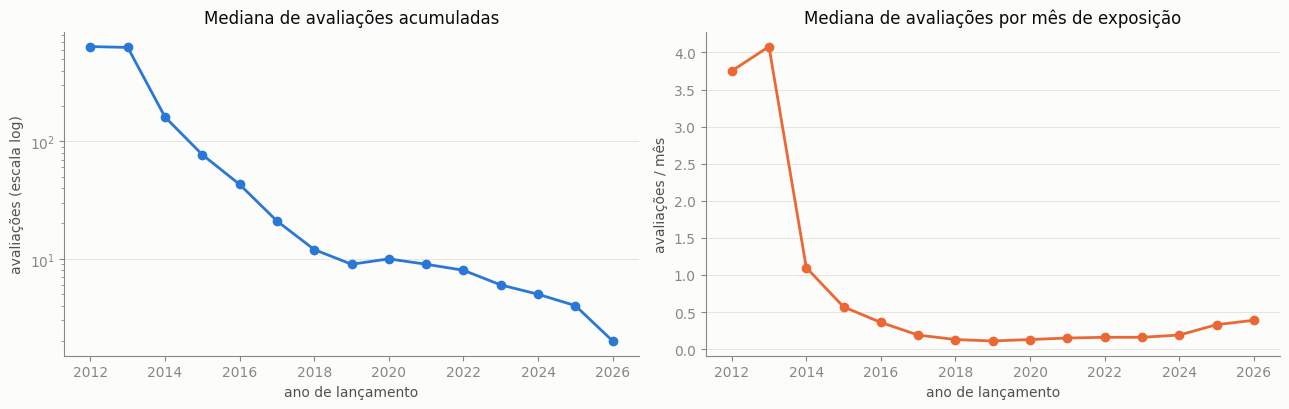

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(tab.index, tab["mediana_acumulada"], marker="o", color=BLUE, linewidth=2)
axes[0].set_title("Mediana de avaliações acumuladas")
axes[0].set_yscale("log")
axes[0].set_ylabel("avaliações (escala log)")

axes[1].plot(tab.index, tab["mediana_por_mes"], marker="o", color=ORANGE, linewidth=2)
axes[1].set_title("Mediana de avaliações por mês de exposição")
axes[1].set_ylabel("avaliações / mês")

for ax in axes:
    ax.set_xlabel("ano de lançamento")
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Isso definitivament não é o que eu esperava kkkkkk**

A série acumulada cai de forma monotônica (641 avaliações em 2012 contra 2 em 2026). 

Já a taxa por mês não cai, ela faz tipo um **U**. Vai de 3,75/mês em 2012 até um piso de 0,11/mês em 2019, e volta a subir até 0,39/mês em 2026.

Minha leitura (me corrija se eu estiver viajando) é que existem dois efeitos sobrepostos, puxando em direções contrárias:

- **Acúmulo de avaliações é concentrado no lançamento.** Um jogo recebe a maior parte das avaliações nos primeiros meses e depois desacelera. Dividir o acumulado de um jogo de 2012 por 170 meses dilui o pico inicial dele num denominador enorme, então a taxa média subestima jogos antigos.
- **A composição do catálogo mudou.** O Steam Direct abriu a plataforma em 2017, e o volume de lançamentos explodiu (297 jogos em 2012 contra 21.015 em 2025). O catálogo recente tem uma proporção muito maior de projetos pequenos.

Ou seja: `release_year` não é só exposição, é exposição **mais** composição do catálogo. Normalizar por tempo troca um viés por outro. Por isso a decisão que tomo aqui é **não usar taxa como variável-alvo**, e sim manter `log1p(reviews_total)` como alvo com `meses_exposicao` entrando como covariável explícita, deixando o modelo estimar o efeito em vez de eu impor uma forma funcional que os dados não sustentam.

*(Professor, esse é um dos pontos que eu gostaria de discutir: uma alternativa seria o GLM Binomial Negativa com `log(exposição)` como offset, que impõe coeficiente 1 para a exposição. Pelo formato em U acima eu desconfio que o coeficiente não seja 1, mas não testei ainda, deixei para a próxima etapa.)*

## 4. Histórico da desenvolvedora

Essa é uma variável nova, e ela existe por causa de uma preocupação específica: parte enorme da popularidade de um jogo vem de coisas que não estão na página da loja, streamer que pegou o jogo, vídeo que viralizou, campanha de divulgação. Nada disso está no `appdetails`, e não dá para observar diretamente.

O que dá para observar é **o histórico do estúdio**: quantos jogos ele já lançou antes e como esses foram. Isso captura, ainda que parcialmente, alcance e capacidade de divulgação, que é boa parte do que gera atenção de mídia.

O cuidado essencial aqui é **não vazar informação do futuro**: para cada jogo, uso apenas lançamentos **estritamente anteriores** da mesma desenvolvedora.

In [10]:
d = df.sort_values("release_date").copy()
g = d.groupby("desenvolvedora", sort=False)

# nº de jogos que a dev já tinha lançado antes desse
d["dev_jogos_ant"] = g.cumcount()

# média de log_reviews dos lançamentos anteriores (shift(1) garante que o próprio
# jogo nunca entra na própria média)
d["dev_log_rev_ant"] = g["log_reviews"].transform(lambda s: s.shift().expanding().mean())

df = d.sort_index()

n_com = int((df.dev_jogos_ant > 0).sum())
print(f"jogos com pelo menos 1 lançamento anterior da mesma dev: {n_com:,} "
      f"({100*n_com/len(df):.1f}%)")

jogos com pelo menos 1 lançamento anterior da mesma dev: 46,792 (39.5%)


In [11]:
faixa = pd.cut(df["dev_jogos_ant"], [-1, 0, 1, 4, 9, 10**6],
               labels=["1º jogo", "2º jogo", "3º–5º", "6º–10º", "11º+"])
tab_dev = (df.groupby(faixa, observed=True)
             .agg(n=("appid", "size"),
                  mediana_reviews=("reviews_total", "median"),
                  pct_sem_avaliacao=("reviews_total", lambda s: (s == 0).mean()))
             .assign(pct_sem_avaliacao=lambda t: (t.pct_sem_avaliacao*100).round(1)))
print(tab_dev.to_string())

                   n  mediana_reviews  pct_sem_avaliacao
dev_jogos_ant                                           
1º jogo        71658              5.0               24.4
2º jogo        16594             12.0               17.8
3º–5º          14348             18.0               14.9
6º–10º          6386             19.0               11.8
11º+            9464             11.0               11.7


O padrão não é monotônico. Sair do primeiro jogo ajuda muito: a mediana vai de 5 para 12 avaliações e a taxa de jogos sem nenhuma avaliação cai de 24,4% para 17,8%. O ganho continua até a faixa de 3 a 10 jogos (mediana 18–19).

Mas na faixa de **11 ou mais lançamentos a mediana cai para 11**. Minha interpretação é que essa faixa é dominada por estúdios de alto volume e baixo investimento por título, as "fábricas" de jogos pequenos que já apareceram na lista de distribuidoras mais frequentes da base. Experiência do estúdio ajuda até certo ponto; volume puro, não.

## 5. Desenho experimental

Duas decisões antes de treinar qualquer coisa.

**Coorte mínima.** Restrinjo a modelagem a jogos com pelo menos 12 meses de mercado. Sem isso eu
estaria pedindo ao modelo que previsse a popularidade final de jogos que mal chegaram na loja. Dá
para ver o tamanho do problema olhando a taxa de jogos sem nenhuma avaliação por tempo de mercado:

In [12]:
faixas = pd.cut(df["meses_exposicao"], [0, 1, 3, 6, 12, 10**4],
                labels=["< 1 mês", "1–3 meses", "3–6 meses", "6–12 meses", "12+ meses"])

tab = (df.assign(faixa=faixas)
         .groupby("faixa", observed=True)
         .agg(jogos=("appid", "size"),
              pct_sem_avaliacao=("reviews_total", lambda s: 100 * (s == 0).mean()))
         .round(1))
print(tab.to_string())

ultimo = df["release_date"].max().to_period("M") - 1     # último mês completo da coleta
recentes = df[df["release_date"].dt.to_period("M") == ultimo]
print()
print(f"lançados em {ultimo}: {len(recentes)} jogos, "
      f"{100 * (recentes.reviews_total == 0).mean():.1f}% sem nenhuma avaliação")

             jogos  pct_sem_avaliacao
faixa                                
< 1 mês         38              100.0
1–3 meses     2148               53.4
3–6 meses     4678               31.6
6–12 meses   11278               27.6
12+ meses   100454               18.6

lançados em 2026-07: 151 jogos, 86.1% sem nenhuma avaliação


Entre os jogos com menos de um mês de loja praticamente nenhum tem avaliação, e no último mês
completo da coleta a taxa ainda passa de 86%. 

o jogo não teve tempo de acumular nada. A partir dos 12 meses a taxa estabiliza perto do patamar da base
inteira, e é por isso que o corte da coorte é ali.

**Partição temporal, não aleatória.** Separo treino e teste por data de lançamento em vez de sortear.
Partição aleatória deixaria jogos de 2025 no treino prevendo jogos de 2019, o que não corresponde ao
uso real (prever um lançamento futuro) e acho que estraga a analise.

In [13]:
CORTE = pd.Timestamp("2024-08-10")   # os últimos 2 anos da base viram teste

mod = df[df["dias_exposicao"] >= 365].copy()
treino = mod[mod.release_date <  CORTE].copy()
teste  = mod[mod.release_date >= CORTE].copy()

print(f"base completa:              {len(df):,}")
print(f"coorte com ≥12 meses:       {len(mod):,}")
print(f"  treino (até 08/2024):     {len(treino):,}")
print(f"  teste  (08/2024–08/2025): {len(teste):,}")
print()
print(f"sem avaliação no treino: {100*(treino.reviews_total==0).mean():.1f}%")
print(f"sem avaliação no teste:  {100*(teste.reviews_total==0).mean():.1f}%")

base completa:              118,596
coorte com ≥12 meses:       100,470
  treino (até 08/2024):     80,788
  teste  (08/2024–08/2025): 19,682

sem avaliação no treino: 16.9%
sem avaliação no teste:  25.9%


A diferença na proporção de zeros entre treino (16,9%) e teste (25,9%) é esperada e eu acho que  vale registrar, mesmo dentro da corte de 12 meses, os jogos do teste são sistematicamente mais novos e tiveram menos tempo de mercado, e é justamente por isso que `meses_exposicao` entra como covariável.

In [14]:
genero_cols   = [c for c in df.columns if c.startswith("genre_")]
categoria_cols = [c for c in df.columns if c.startswith("cat_")]

FEATURES = ([
    "is_free", "preco_brl", "achievements_total", "required_age",
    "supported_languages_count", "dlc_count", "has_demos",
    "windows", "mac", "linux",
    "n_screenshots", "n_videos", "tem_trailer", "tem_site", "n_pacotes",
    "desc_curta_chars", "desc_longa_chars",
    "n_descritores_conteudo", "conteudo_adulto",
    "req_min_chars", "tem_req_recomendado",
    "auto_publicado", "n_desenvolvedoras",
    "dev_jogos_ant", "dev_log_rev_ant",
    "meses_exposicao",
] + genero_cols + categoria_cols)

def montar_X(dados):
    X = dados[FEATURES].copy()
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)
    # preço faltante (as 2 mil moedas estrangeiras) e dev sem histórico viram 0
    return X.astype(float).fillna(0.0)

X_treino, X_teste = montar_X(treino), montar_X(teste)
print(f"{len(FEATURES)} variáveis preditoras")

53 variáveis preditoras


Fora do conjunto de preditoras, de propósito: `reviews_positive`, `reviews_negative` e `review_ratio` (usadas para derivar o alvo), `recommendations_total` (a coluna legada da V1, com 82% de faltante), `metacritic_score` (96,6% de faltante, decisão que já vinha do EDA), e os identificadores `appid` e `name`.

## 6. Modelo de barreira (*hurdle*)

Aqui eu volto na primeira ponta solta do EDA. o `is_free` com correlação negativa que eu tinha achado estranho.

A ideia do modelo de barreira é separar o problema em dois, porque são duas perguntas diferentes:

- **Parte 1:** o jogo consegue receber **alguma** avaliação? (classificação)
- **Parte 2:** dado que recebeu, **quantas**? (regressão)

Isso resolve de uma vez os 20,6% de jogos com zero avaliações, que a Rafaela tinha tratado com um filtro de no mínimo 5 avaliações, descartando-os, e permite ver se `is_free` age de forma diferente nas duas etapas.

In [15]:
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestRegressor,
                              HistGradientBoostingRegressor,
                              HistGradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             mean_absolute_error, mean_squared_error, r2_score)

y_treino_bin = (treino["reviews_total"] > 0).astype(int)
y_teste_bin  = (teste["reviews_total"]  > 0).astype(int)

escala = StandardScaler().fit(X_treino)

reg_log = LogisticRegression(max_iter=2000).fit(escala.transform(X_treino), y_treino_bin)
p_log   = reg_log.predict_proba(escala.transform(X_teste))[:, 1]

gb_clf = HistGradientBoostingClassifier(max_iter=300, random_state=0).fit(X_treino, y_treino_bin)
p_gb   = gb_clf.predict_proba(X_teste)[:, 1]

print("PARTE 1 — P(recebe alguma avaliação)\n")
print(f"prevalência no teste: {y_teste_bin.mean():.3f}\n")
for nome, p in [("Regressão logística", p_log), ("Gradient boosting", p_gb)]:
    print(f"  {nome:22s} AUC {roc_auc_score(y_teste_bin, p):.4f}   "
          f"AP {average_precision_score(y_teste_bin, p):.4f}")

PARTE 1 — P(recebe alguma avaliação)

prevalência no teste: 0.741

  Regressão logística    AUC 0.8788   AP 0.9452
  Gradient boosting      AUC 0.8993   AP 0.9572


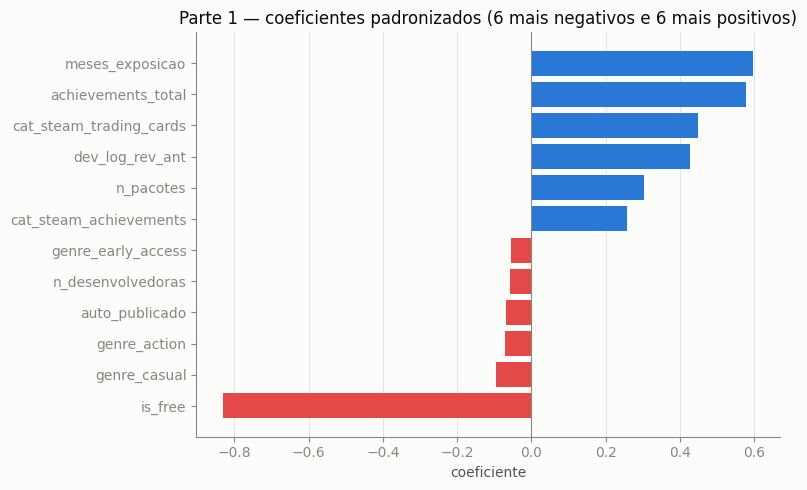

coeficiente de is_free na Parte 1: -0.8316


In [16]:
coef1 = pd.Series(reg_log.coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
sel = pd.concat([coef1.head(6), coef1.tail(6)])
ax.barh(sel.index, sel.values, color=[RED if v < 0 else BLUE for v in sel.values])
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_title("Parte 1 — coeficientes padronizados (6 mais negativos e 6 mais positivos)")
ax.set_xlabel("coeficiente")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"coeficiente de is_free na Parte 1: {coef1['is_free']:.4f}")

`is_free` é o coeficiente **mais negativo do modelo inteiro** (−0,83), com folga sobre o segundo. Ou seja: ser gratuito é, isoladamente, o maior fator contra um jogo conseguir sair do zero. Isso confirma a leitura de composição que eu tinha proposto no EDAm a categoria "grátis" está dominada por projetos pequenos que nunca ganham tração.

Do lado positivo aparecem `meses_exposicao` (esperado), `achievements_total`, `cat_steam_trading_cards` e o `dev_log_rev_ant` que acabei de construir, o histórico da desenvolvedora está entre as variáveis mais fortes já na primeira etapa.

In [17]:
treino2 = treino[treino["reviews_total"] > 0]
teste2  = teste[teste["reviews_total"]  > 0]
X_tr2, X_te2 = montar_X(treino2), montar_X(teste2)
y_tr2, y_te2 = treino2["log_reviews"], teste2["log_reviews"]

print(f"PARTE 2 — log1p(avaliações) | avaliações > 0")
print(f"treino {len(treino2):,} | teste {len(teste2):,}\n")

escala2 = StandardScaler().fit(X_tr2)
resultados = {}

resultados["H0 — mediana"] = np.full(len(y_te2), y_tr2.median())

ridge = Ridge(alpha=1.0).fit(escala2.transform(X_tr2), y_tr2)
resultados["H1 — Ridge"] = ridge.predict(escala2.transform(X_te2))

rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                           n_jobs=-1, random_state=0).fit(X_tr2, y_tr2)
resultados["H2 — Random Forest"] = rf.predict(X_te2)

gb = HistGradientBoostingRegressor(max_iter=400, random_state=0).fit(X_tr2, y_tr2)
resultados["H3 — Gradient boosting"] = gb.predict(X_te2)

placar = pd.DataFrame([{
    "modelo": nome,
    "MAE":  mean_absolute_error(y_te2, pred),
    "RMSE": mean_squared_error(y_te2, pred) ** 0.5,
    "R²":   r2_score(y_te2, pred),
} for nome, pred in resultados.items()]).set_index("modelo").round(4)
print(placar.to_string())

PARTE 2 — log1p(avaliações) | avaliações > 0
treino 67,169 | teste 14,590



                           MAE    RMSE      R²
modelo                                        
H0 — mediana            1.5706  1.9830 -0.0012
H1 — Ridge              1.1548  1.5105  0.4191
H2 — Random Forest      1.0436  1.3589  0.5298
H3 — Gradient boosting  1.0014  1.3162  0.5589


A escada funciona: sai de R² zero no baseline trivial para 0,56 com boosting, e o erro absoluto médio cai de 1,57 para 1,00 em escala log. O Random Forest (que foi o teto do trabalho da Rafaela) fica em 0,53, e o boosting acrescenta mais 0,03 em cima disso.

Agora o ponto que eu queria testar, e que **não deu o que eu esperava**:

In [18]:
coef2 = pd.Series(ridge.coef_, index=FEATURES).sort_values()
print(f"coeficiente de is_free na Parte 1 (barreira):   {coef1['is_free']:.4f}")
print(f"coeficiente de is_free na Parte 2 (magnitude):  {coef2['is_free']:.4f}")
print()
print("Mediana de avaliações entre os que TÊM alguma avaliação:")
print(mod[mod.reviews_total > 0].groupby("is_free")["reviews_total"].median().to_string())

coeficiente de is_free na Parte 1 (barreira):   -0.8316
coeficiente de is_free na Parte 2 (magnitude):  -0.6089

Mediana de avaliações entre os que TÊM alguma avaliação:
is_free
False    18.0
True      7.0


Minha hipótese de trabalho era que `is_free` teria **sinais opostos** nas duas partes: penalizaria a chance de sair do zero, mas favoreceria a magnitude entre os que saem, até pq os cinco jogos mais avaliados da plataforma inteira são todos gratuitos (Counter-Strike 2, PUBG, Rainbow Six Siege, NARAKA, Z1).

**Não é o que acontece.** O coeficiente é negativo nas duas etapas (−0,83 e −0,61), e a mediana condicional parece confirmar, que entre os jogos que têm pelo menos uma avaliação, gratuito tem mediana 7 contra 18 dos pagos.

A explicação me parece é que aqueles cinco gigantes são pouquíssimos casos num universo de 17.570 jogos gratuitos. Eles dominam a soma total de avaliações, mas não movem a mediana nem o coeficiente. Então, acho que uma conclusão correta é: **ser gratuito é desvantagem nas duas etapas**, e a intuição de que "F2P tem mais jogadores" vale para um punhado de títulos, não para a categoria.

Isso também esclarece o −67,9% que a Rafaela estimou para `is_free` no GLM Poisson dela: o sinal estava certo, mas o filtro de no mínimo 5 avaliações que ela aplicou removeu justamente a etapa em que o efeito é mais forte.

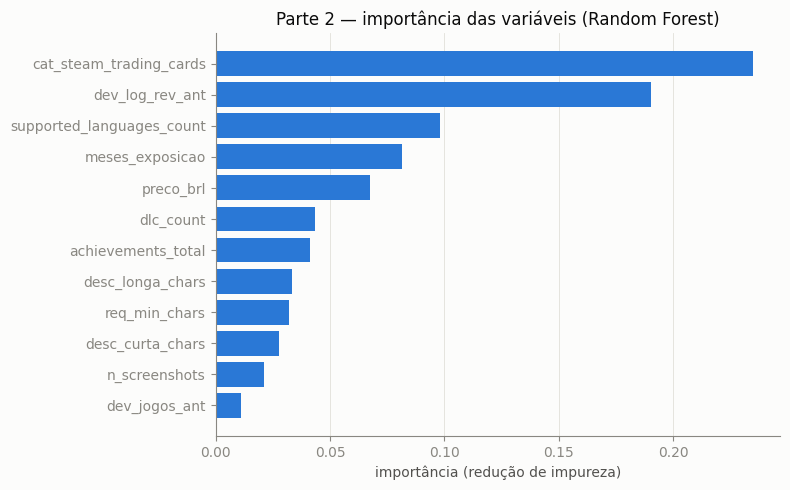

cat_steam_trading_cards      0.2349
dev_log_rev_ant              0.1900
supported_languages_count    0.0982
meses_exposicao              0.0816
preco_brl                    0.0676
dlc_count                    0.0434
achievements_total           0.0414
desc_longa_chars             0.0332
req_min_chars                0.0320
desc_curta_chars             0.0276
n_screenshots                0.0213
dev_jogos_ant                0.0111


In [19]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index[::-1], imp.values[::-1], color=BLUE)
ax.set_title("Parte 2 — importância das variáveis (Random Forest)")
ax.set_xlabel("importância (redução de impureza)")
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()
print(imp.round(4).to_string())

Duas coisas chamam atenção aqui.

A primeira é que **`dev_log_rev_ant` é a segunda variável mais importante do modelo** (0,19), atrás só de `cat_steam_trading_cards`. Como ela não existia na base até esse notebook e saiu de graça do checkpoint, é um bom argumento a favor de continuar explorando o que ainda está lá dentro sem ter sido aproveitado.

A segunda é um problema. **`cat_steam_trading_cards` domina o modelo com 0,235**, e eu já tinha registrado no EDA que essa variável é suspeita: a Valve libera cartas colecionáveis para jogos que já são populares. Ou seja, ela é em boa parte *consequência* da popularidade, não causa. Um modelo que se apoia nela está usando informação posterior ao fenômeno que quer prever.

Não removi ela ainda porque quero medir o custo dessa remoção antes de decidir, mas essa é a próxima coisa que pretendo testar.

## 7. GLM Poisson vs Binomial Negativa

Essa seção existe por dois motivos. O primeiro é responder formalmente a pergunta que eu deixei em aberto na seção 3: o coeficiente da exposição é mesmo 1, como o offset assume? O segundo é fazer a comparação direta com o TCC da Rafaela, que modelou `total_reviews` com um GLM Poisson.

Olhando a Tabela 5.4 do trabalho dela, todos os coeficientes saem com p-valor 0 e valores z entre 1.000 e 4.000. Isso é assinatura de **superdispersão**: a Poisson assume que a variância é igual à média, e quando a variância real é muito maior, os erros-padrão saem subestimados e a significância vira artefato do modelo, não evidência nos dados.

Ajusto as duas famílias na mesma especificação, mudando só a distribuição, para isolar o efeito.

In [20]:
import statsmodels.api as sm
from scipy import stats

# Contínuas padronizadas (ajuda a convergência e torna os coeficientes comparáveis);
# binárias ficam em 0/1 para que exp(coef) seja lido como efeito multiplicativo.
CONTINUAS = ["preco_brl", "achievements_total", "required_age", "supported_languages_count",
             "dlc_count", "n_screenshots", "n_videos", "n_pacotes", "desc_curta_chars",
             "desc_longa_chars", "n_descritores_conteudo", "req_min_chars",
             "n_desenvolvedoras", "dev_jogos_ant", "dev_log_rev_ant"]
BINARIAS = (["is_free", "has_demos", "windows", "mac", "linux", "tem_trailer", "tem_site",
             "conteudo_adulto", "tem_req_recomendado", "auto_publicado"]
            + genero_cols + categoria_cols)

media = treino[CONTINUAS].fillna(0.0).mean()
desvio = treino[CONTINUAS].fillna(0.0).std().replace(0, 1.0)

def desenho(dados, exposicao_livre=False):
    X = pd.DataFrame(index=dados.index)
    X[CONTINUAS] = (dados[CONTINUAS].fillna(0.0) - media) / desvio
    for c in BINARIAS:
        X[c] = dados[c].astype(float)
    if exposicao_livre:
        X["log_exposicao"] = np.log(dados["meses_exposicao"])
    return sm.add_constant(X, has_constant="add")

X_glm_tr = desenho(treino)
X_glm_te = desenho(teste)[X_glm_tr.columns]
y_glm_tr = treino["reviews_total"].astype(float)
y_glm_te = teste["reviews_total"].astype(float)
offset_tr = np.log(treino["meses_exposicao"])
offset_te = np.log(teste["meses_exposicao"])

poisson = sm.GLM(y_glm_tr, X_glm_tr, family=sm.families.Poisson(),
                 offset=offset_tr).fit()

z_poisson = (poisson.params / poisson.bse).abs()
print(f"convergiu: {poisson.converged}")
print(f"Pearson χ²/gl : {poisson.pearson_chi2/poisson.df_resid:,.1f}   (1,0 seria equidispersão)")
print(f"|z| mediano   : {z_poisson.median():,.0f}")
print(f"|z| máximo    : {z_poisson.max():,.0f}")
print(f"coeficientes com p < 0,001         : {(poisson.pvalues < 0.001).sum()} de {len(poisson.pvalues)}")
print(f"coeficientes com p exatamente 0,000: {(poisson.pvalues == 0).sum()}")

convergiu: True
Pearson χ²/gl : 36,736.8   (1,0 seria equidispersão)
|z| mediano   : 1,152
|z| máximo    : 5,799
coeficientes com p < 0,001         : 53 de 53
coeficientes com p exatamente 0,000: 52


A estatística de Pearson dividida pelos graus de liberdade dá **36.737**, quando equidispersão daria 1. E o padrão reproduz exatamente o que aparece na tabela da Rafaela: 52 dos 53 coeficientes com p-valor exatamente zero, e valores z com mediana de 1.152.

A o que a Poisson faz com essa variável-resposta em qualquer recorte da base. Isso confirma a leitura de que a significância universal daquele modelo é artefato de especificação.

A Binomial Negativa acrescenta um parâmetro de dispersão α, com Var(Y) = μ + αμ². Estimo α por máxima verossimilhança junto com os coeficientes, em vez de fixá-lo por método de momentos.

In [21]:
inicio = np.append(poisson.params.values, np.log(3.3))
neg_bin = sm.NegativeBinomial(y_glm_tr, X_glm_tr, offset=offset_tr.values,
                              loglike_method="nb2").fit(start_params=inicio,
                                                        method="bfgs", maxiter=400, disp=0)

alpha = float(neg_bin.params.iloc[-1])
z_nb = (neg_bin.params[:-1] / neg_bin.bse[:-1]).abs()

print(f"convergiu: {neg_bin.mle_retvals['converged']}")
print(f"α estimado : {alpha:.4f}   →   Var(Y) = μ + {alpha:.3f}·μ²")
print(f"|z| mediano: {z_nb.median():.1f}    (Poisson: {z_poisson.median():,.0f})")
print(f"|z| máximo : {z_nb.max():.1f}    (Poisson: {z_poisson.max():,.0f})")
print(f"erro-padrão NB / Poisson (mediana): {(neg_bin.bse[:-1]/poisson.bse).median():.0f}× maior")

LR = 2 * (neg_bin.llf - poisson.llf)
print(f"\nTeste de razão de verossimilhanças — H0: α = 0 (a Poisson)")
print(f"  LR = {LR:,.0f}   p = {0.5*stats.chi2.sf(LR, 1):.3g}")
print("  (teste de fronteira: p dividido por 2, pois α = 0 está no limite do espaço paramétrico)")

convergiu: True
α estimado : 3.7136   →   Var(Y) = μ + 3.714·μ²
|z| mediano: 15.2    (Poisson: 1,152)
|z| máximo : 51.8    (Poisson: 5,799)
erro-padrão NB / Poisson (mediana): 80× maior

Teste de razão de verossimilhanças — H0: α = 0 (a Poisson)
  LR = 343,706,039   p = 0
  (teste de fronteira: p dividido por 2, pois α = 0 está no limite do espaço paramétrico)


In [22]:
perdem = neg_bin.pvalues[:-1][neg_bin.pvalues[:-1] >= 0.05].sort_values(ascending=False)
print(f"variáveis não significativas sob a Binomial Negativa: {len(perdem)} de {len(z_nb)}\n")
for nome, p in perdem.items():
    print(f"  {nome:26s} p = {p:.3f}   →   sob a Poisson era p = {poisson.pvalues[nome]:.2e}")

variáveis não significativas sob a Binomial Negativa: 3 de 53

  desc_curta_chars           p = 0.912   →   sob a Poisson era p = 0.00e+00
  cat_vr_support             p = 0.769   →   sob a Poisson era p = 0.00e+00
  has_demos                  p = 0.293   →   sob a Poisson era p = 0.00e+00


A Poisson é rejeitada sem margem para dúvida. Os erros-padrão da Binomial Negativa são **80 vezes maiores** na mediana, e a mediana dos |z| cai de 1.152 para 15,2.

**três variáveis deixam de ser significativas**: `desc_curta_chars`, `cat_vr_support` e `has_demos`. Todas as três apareciam com p-valor exatamente zero sob a Poisson.

In [23]:
destaque = ["is_free", "cat_single-player", "cat_multi-player", "cat_online_pvp",
            "cat_steam_trading_cards", "cat_steam_workshop", "required_age",
            "supported_languages_count", "dev_log_rev_ant", "achievements_total",
            "genre_indie"]
comparacao = pd.DataFrame([{
    "variável":    v,
    "coef Poisson": poisson.params[v],
    "z Poisson":    poisson.params[v] / poisson.bse[v],
    "coef NB":      neg_bin.params[v],
    "z NB":         neg_bin.params[v] / neg_bin.bse[v],
    "efeito NB %":  (np.exp(neg_bin.params[v]) - 1) * 100,
} for v in destaque]).set_index("variável").round(2)
comparacao

,coef Poisson,z Poisson,coef NB,z NB,efeito NB %
variável,,,,,
is_free,-0.66,-1168.23,-3.15,-32.29,-95.70
cat_single-player,-0.86,-2116.35,-1.23,-23.41,-70.70
cat_multi-player,0.88,2400.99,0.70,16.05,100.69
cat_online_pvp,0.95,819.58,0.92,17.72,151.21
cat_steam_trading_cards,0.76,2847.53,1.04,47.83,183.45
cat_steam_workshop,0.77,2519.54,1.13,24.93,210.11
required_age,0.13,1363.37,0.13,16.87,13.41
supported_languages_count,0.46,5798.69,0.31,21.62,36.48
dev_log_rev_ant,0.21,2852.21,0.34,51.77,40.63


Duas leituras dessa tabela.

`is_free` fica muito mais forte sob a Binomial Negativa: de −0,66 para −3,15, o que em efeito multiplicativo é **−95,7%**. Coerente com o que o modelo de barreira já tinha mostrado na seção 6.

E `genre_indie` **troca de sinal** de −0,54 sob a Poisson para +0,16 sob a NB. Como no EDA eu tinha concluído que "indie" funciona mais como rótulo de modelo de publicação do que como gênero de conteúdo, essa instabilidade mme  parece que merece cautela, pq o sinal dessa variável depende da especificação, então não vou construir afirmação nenhuma em cima dele. (a não ser que tu tenha alguma visão diferente professor.)

### A exposição entra como offset ou como coeficiente livre?

Essa é a pergunta que ficou pendente na seção 3. Usar `log(exposição)` como offset equivale a **impor** que o coeficiente dela seja exatamente 1, ou seja, que dobrar o tempo de mercado dobre o número esperado de avaliações. Eu imaginei que da pra testar isso, então, deixei a variável entrar livre e verificar se o intervalo de confiança cobre 1.

In [24]:
X_livre_tr = desenho(treino, exposicao_livre=True)
X_livre_te = desenho(teste,  exposicao_livre=True)[X_livre_tr.columns]

inicio2 = np.append(np.append(neg_bin.params[:-1].values, 1.0), neg_bin.params.iloc[-1])
nb_livre = sm.NegativeBinomial(y_glm_tr, X_livre_tr, loglike_method="nb2").fit(
                start_params=inicio2, method="bfgs", maxiter=400, disp=0)

b  = nb_livre.params["log_exposicao"]
se = nb_livre.bse["log_exposicao"]
z1 = (b - 1) / se

print(f"convergiu: {nb_livre.mle_retvals['converged']}\n")
print(f"coeficiente de log(exposição): {b:.4f}   (erro-padrão {se:.4f})")
print(f"IC 95%: [{b - 1.96*se:.4f}, {b + 1.96*se:.4f}]")
print(f"\nH0: coeficiente = 1  →  z = {z1:.2f}   p = {2*stats.norm.sf(abs(z1)):.3g}")

convergiu: True

coeficiente de log(exposição): 0.7062   (erro-padrão 0.0150)
IC 95%: [0.6767, 0.7356]

H0: coeficiente = 1  →  z = -19.57   p = 2.65e-85


**O coeficiente é 0,71, com intervalo de confiança [0,68; 0,74] --> que não chega perto de 1.** A hipótese é rejeitada com z = −19,57.

Isso confirma formalmente a desconfiança que eu tinha levantado na seção 3 a partir do formato em U da taxa por mês. O acúmulo de avaliações é **sublinear** no tempo de exposição: dobrar o tempo de mercado multiplica as avaliações esperadas por 2^0,71 ≈ 1,64, não por 2. É exatamente o que se espera quando as avaliações se concentram nos primeiros meses e depois desaceleram.

Ou seja, o offset,  que é o tratamento de manual para contagem com janelas desiguais, impõe aqui uma restrição que os dados rejeitam.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def previsao(params, X, offset=None):
    eta = X.values @ np.asarray(params, dtype=float)
    if offset is not None:
        eta = eta + np.asarray(offset, dtype=float)
    return np.exp(np.clip(eta, -30, 30))

y_log_te = np.log1p(y_glm_te)
modelos_glm = {
    "Poisson (offset)":                poisson.predict(X_glm_te, offset=offset_te),
    "Binomial Negativa (offset)":      previsao(neg_bin.params[:-1], X_glm_te, offset_te),
    "Binomial Negativa (exp. livre)":  previsao(nb_livre.params[:-1], X_livre_te),
}
placar_glm = pd.DataFrame([{
    "modelo": nome,
    "MAE":  mean_absolute_error(y_log_te, np.log1p(np.clip(p, 0, None))),
    "RMSE": mean_squared_error(y_log_te, np.log1p(np.clip(p, 0, None))) ** 0.5,
    "R²":   r2_score(y_log_te, np.log1p(np.clip(p, 0, None))),
} for nome, p in modelos_glm.items()]).set_index("modelo").round(4)
print(placar_glm.to_string())

                                   MAE    RMSE      R²
modelo                                                
Poisson (offset)                2.1137  2.5377 -0.4139
Binomial Negativa (offset)      1.5424  1.9433  0.1709
Binomial Negativa (exp. livre)  1.7078  2.1009  0.0310


A Poisson tem **R² negativo (−0,41)** fora da amostra, ou seja, prevê pior que simplesmente chutar a média que era de se esperar dado o diagnóstico de superdispersão. A Binomial Negativa com offset sobe para 0,17.

Mas a versão com exposição livre, que é a **estatisticamente correta** pelo teste que acabei de fazer, prevê **pior** fora da amostra (R² 0,03) do que a versão com offset (0,17). Minha hipótese é que o conjunto de teste é sistematicamente mais novo que o de treino, e o coeficiente 0,71 estimado no treino extrapola mal para janelas de exposição curtas, enquanto a restrição do offset acaba funcionando como regularização.

Uma ressalva importante para não me confundir depois: **esses R² não são comparáveis com os da seção 6**. Aqui a previsão é sobre os 19.682 jogos do teste inteiro, incluindo os que têm zero avaliações; lá era sobre os 14.590 que já tinham pelo menos uma. São amostras diferentes, e o modelo de barreira existe justamente porque tratar as duas populações junto é o que atrapalha.

## 8. Síntese

| Etapa | O que ficou estabelecido |
|---|---|
| Preço | `price_brl` misturava moedas (2.000 apps em IDR, VND, USD e outras). Corrigido para BRL-apenas; média dos pagos cai de R$ 206,12 para R$ 25,55, sem perder linha da base |
| Exposição | Normalizar por tempo **não** resolve o viés, a taxa por mês faz um U, porque acúmulo é concentrado no lançamento e o catálogo mudou de composição após o Steam Direct |
| Exposição (formal) | O coeficiente de `log(exposição)` é **0,71**, IC 95% [0,68; 0,74], rejeitando a hipótese de que seja 1. O acúmulo é sublinear: dobrar o tempo de mercado multiplica as avaliações por ≈1,64, não por 2 |
| Histórico de estúdio | Variável nova, sem coleta adicional. Efeito não-monotônico: sair do 1º jogo ajuda muito, mas estúdios com 11+ lançamentos voltam a cair. Segunda variável mais importante do modelo |
| Barreira | Separar "recebe avaliação?" de "quantas?" permite modelar os 20,6% de zeros em vez de descartá-los por filtro |
| `is_free` | Negativo nas **duas** etapas (−0,83 e −0,61). Minha hipótese de sinais opostos estava errada; a intuição de "F2P tem mais público" vale para uns cinco títulos, não para a categoria |
| Poisson | Pearson χ²/gl = **36.737**, com 52 dos 53 coeficientes em p-valor exatamente zero. Reproduz a patologia da Tabela 5.4 da Rafaela, e mostra que ela não vem do recorte indie |
| Binomial Negativa | α = 3,71 estimado por máxima verossimilhança; Poisson rejeitada pelo teste de razão de verossimilhanças. Erros-padrão 80× maiores, e `desc_curta_chars`, `cat_vr_support` e `has_demos` deixam de ser significativas |
| Desempenho | Parte 2 do modelo de barreira: R² de 0 (baseline) → 0,42 (Ridge) → 0,53 (Random Forest) → 0,56 (boosting) |
| Ressalva | `cat_steam_trading_cards` domina a importância, mas é provavelmente consequência da popularidade, não causa. Precisa ser tratada |